# Emergent-constraint examples and individual reconstruction constraints

A 2 × 3 figure for 1965–2021. Row 1 shows one representative emergent-constraint relationship for each depth domain. Row 2 shows the six individual reconstruction-specific EC uncertainty distributions rather than their final mixture.


In [1]:
from pathlib import Path
import os
import pickle
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-emergent-constraint-summary')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from scipy.stats import linregress, t

PYTHON_FUNCTIONS = Path('/scratch/gpfs/GEOCLIM/LRGROUP/db9274/Analysis/Python_functions')
if str(PYTHON_FUNCTIONS) not in sys.path:
    sys.path.append(str(PYTHON_FUNCTIONS))
from emergent_constraint_tests import (
    ECDistribution, build_xgrid, compute_component_pdfs,
)

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
})

ROOT = Path('/scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures')
PERIOD = (1965, 2021)
MIN_TREND_YEARS = 20
EC_CI = 0.95
CACHE_DIR = ROOT / 'cache_three_panel_o2_potden_en4_1965_2021'
DEPTHS = {
    'Full water column': {
        'file': CACHE_DIR / 'full_depth_plot_data_1965_2021_6_products_olivelli_potden_en4_v2.pkl',
    },
    'Upper 2000 m': {
        'file': CACHE_DIR / 'upper_2000m_plot_data_1965_2021_6_products_olivelli_potden_en4_v2.pkl',
    },
    'Below 2000 m': {
        'file': CACHE_DIR / 'below_2000m_plot_data_1965_2021_6_products_olivelli_potden_en4_v2.pkl',
    },
}
PRODUCT_ORDER = [
    'Ito(2022; 5 year)',
    'Ito(2024; NN)',
    'Ito(2024; RF)',
    'Gouretski(2024)',
    'Roach and Bindoff',
    'Olivelli(2026)',
]
PRODUCT_STYLES = {
    'Ito(2022; 5 year)': {'color': '#0072B2', 'marker': 's'},
    'Ito(2024; NN)': {'color': '#009E73', 'marker': '^'},
    'Ito(2024; RF)': {'color': '#D55E00', 'marker': 'o'},
    'Gouretski(2024)': {'color': '#CC79A7', 'marker': 'D'},
    'Roach and Bindoff': {'color': '#E69F00', 'marker': 'P'},
    'Olivelli(2026)': {'color': '#7B2CBF', 'marker': 'X'},
}
PRODUCT_LABELS = {
    'Ito(2022; 5 year)': 'Ito (2022)',
    'Ito(2024; NN)': 'Ito et al. (2024): Neural network',
    'Ito(2024; RF)': 'Ito et al. (2024): Random forest',
    'Gouretski(2024)': 'Gouretski et al. (2024)',
    'Roach and Bindoff': 'Roach & Bindoff (2023)',
    'Olivelli(2026)': 'Olivelli et al. (2026)',
}
PRODUCT_CACHE_KEYS = {
    'Ito(2022; 5 year)': 'Ito (2022)',
    'Ito(2024; NN)': 'Ito et al. (2024): Neural network',
    'Ito(2024; RF)': 'Ito et al. (2024): Random forest',
    'Gouretski(2024)': 'Gouretski et al. (2024)',
    'Roach and Bindoff': 'Roach & Bindoff (2023)',
    'Olivelli(2026)': 'Olivelli et al. (2026)',
}
GAP_FILLED_BOX_FACE = '#DCEEF8'
EC_MIXTURE_BOX_FACE = '#FBE3D4'
BOX_EDGE = '0.15'

OUTPUT_STEM = Path.cwd() / 'Figures/emergent_constraint_examples_and_individual_ec_1965_2021'

for path in [cfg['file'] for cfg in DEPTHS.values()]:
    if not path.exists():
        raise FileNotFoundError(path)

print(f'Input directory: {ROOT}')
print('Depth comparisons: ' + ', '.join(DEPTHS))


Input directory: /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures
Depth comparisons: Full water column, Upper 2000 m, Below 2000 m


## Build product-level emergent constraints

Product ECs for all three depth domains are calculated directly from the rebuilt cached time series. The same significance and positive-slope validity rule is applied consistently to every domain.


In [2]:
def deoxygenation_per_decade(series, start=PERIOD[0], end=PERIOD[1]):
    clean = series.loc[start:end].dropna()
    if len(clean) < MIN_TREND_YEARS:
        return np.nan
    return -10.0 * linregress(clean.index.astype(float), clean.to_numpy(float)).slope


def regression_with_confidence_band(paired, x_grid, ci=EC_CI):
    x = paired['gap_filled'].to_numpy(float)
    y = paired['fully_sampled'].to_numpy(float)
    fit = linregress(x, y)
    y_fit = fit.intercept + fit.slope * x_grid

    residuals = y - (fit.intercept + fit.slope * x)
    dof = len(x) - 2
    residual_se = np.sqrt(np.sum(residuals**2) / dof)
    sxx = np.sum((x - x.mean())**2)
    mean_se = residual_se * np.sqrt(1 / len(x) + (x_grid - x.mean())**2 / sxx)
    critical = t.ppf(1 - (1 - ci) / 2, dof)
    return fit, y_fit, y_fit - critical * mean_se, y_fit + critical * mean_se


def product_ec_from_cache(depth_label, depth_file, product):
    cache_product = PRODUCT_CACHE_KEYS[product]
    with depth_file.open('rb') as handle:
        cached = pickle.load(handle)
    result = cached['ec_trend'][cache_product]
    valid = bool(result.get('significant_positive_slope', False))
    return {
        'depth_label': depth_label, 'basin_index': 0, 'basin': 'Global',
        'product': product, 'gapfilled': float(result['obs_y']),
        'ec': float(result['x_ec']), 'lo': float(result['x_lo']),
        'hi': float(result['x_hi']), 'r': float(result['rvalue']),
        'p': float(result['pvalue']), 'slope': float(result['slope']),
        'intercept': float(result['intercept']), 'valid_for_plot': valid,
        'flag': result.get('ec_flag', 'ok' if valid else 'invalid'),
        'calculation_version': result.get('calculation_version', 'cached'),
    }

def load_example_relation(depth_label, product):
    depth_file = DEPTHS[depth_label]['file']
    cache_product = PRODUCT_CACHE_KEYS[product]
    with depth_file.open('rb') as handle:
        cached = pickle.load(handle)

    full = pd.Series({
        model: deoxygenation_per_decade(series)
        for model, series in cached['model_ts'].items()
    }, name='fully_sampled')
    gap = pd.Series({
        model: deoxygenation_per_decade(series)
        for model, series in cached['gap_ts'][cache_product].items()
    }, name='gap_filled')
    paired = pd.concat([gap, full], axis=1).dropna()
    observed = deoxygenation_per_decade(cached['obs_ts'][cache_product])
    return paired, observed


EXAMPLE_RELATIONS = {
    'Full water column': 'Olivelli(2026)',
    'Upper 2000 m': 'Ito(2024; NN)',
    'Below 2000 m': 'Roach and Bindoff',
}
examples = {}
for depth, product in EXAMPLE_RELATIONS.items():
    paired, observed = load_example_relation(depth, product)
    examples[depth] = {'product': product, 'paired': paired, 'observed': observed}


all_ec = pd.DataFrame([
    product_ec_from_cache(depth_label, depth_cfg['file'], product)
    for depth_label, depth_cfg in DEPTHS.items()
    for product in PRODUCT_ORDER
])
global_ec = all_ec.loc[all_ec['valid_for_plot']].copy()
global_ec['product'] = pd.Categorical(global_ec['product'], PRODUCT_ORDER, ordered=True)
global_ec['depth_label'] = pd.Categorical(global_ec['depth_label'], list(DEPTHS), ordered=True)
global_ec = global_ec.sort_values(['depth_label', 'product']).reset_index(drop=True)

global_ec[['depth_label', 'product', 'gapfilled', 'ec', 'lo', 'hi', 'r', 'p']]


,depth_label,product,gapfilled,ec,lo,hi,r,p
0,Full water column,Ito(2022; 5 year),0.461314,0.691713,0.589964,0.793463,0.956511,8.890910e-08
1,Full water column,Ito(2024; NN),0.646854,0.441832,0.270236,0.613428,0.717679,3.851842e-03
2,Full water column,Ito(2024; RF),0.516460,0.605212,0.438165,0.772260,0.858016,8.649424e-05
3,Full water column,Gouretski(2024),0.406487,0.432335,0.406973,0.457698,0.989780,1.609266e-11
4,Full water column,Olivelli(2026),0.294246,0.342723,0.164057,0.521389,0.537314,4.753944e-02
5,Upper 2000 m,Ito(2022; 5 year),0.778405,0.929216,0.767021,1.091410,0.937454,7.546376e-07
6,Upper 2000 m,Ito(2024; NN),0.856919,0.525029,0.242449,0.807609,0.541128,4.568655e-02
7,Upper 2000 m,Ito(2024; RF),0.749752,0.941236,0.620101,1.262370,0.809870,4.466329e-04
8,Upper 2000 m,Gouretski(2024),0.584991,0.636214,0.556720,0.715708,0.954837,1.111222e-07
9,Upper 2000 m,Olivelli(2026),0.549519,0.580041,0.410956,0.749126,0.791253,7.491782e-04


## Build equal-weight skew-normal mixtures

Every retained product contributes one normalized skew-normal component with identical weight. Summary boxes span the interquartile range, with whiskers at the 2.5th and 97.5th percentiles.


In [3]:
def normalized_pdf(x, density):
    area = np.trapz(density, x)
    if not np.isfinite(area) or area <= 0:
        raise ValueError('Cannot normalize mixture PDF.')
    return density / area


def quantile_from_pdf(x, pdf, probability):
    increments = 0.5 * (pdf[1:] + pdf[:-1]) * np.diff(x)
    cdf = np.concatenate([[0.0], np.cumsum(increments)])
    cdf /= cdf[-1]
    return float(np.interp(probability, cdf, x))


def equal_weight_skewnormal_mixture(rows, ci=EC_CI, n_grid=12000):
    distributions = [
        ECDistribution(
            label=str(row['product']), ec=float(row['ec']), lower=float(row['lo']),
            upper=float(row['hi']), color=PRODUCT_STYLES[str(row['product'])]['color'],
            weight=1.0,
        )
        for _, row in rows.iterrows()
        if np.all(np.isfinite([row['ec'], row['lo'], row['hi']]))
        and row['lo'] < row['ec'] < row['hi']
    ]
    if not distributions:
        raise ValueError('No valid skew-normal components remain.')

    x = build_xgrid(distributions, physical_min=None, ngrid=n_grid)
    components, _ = compute_component_pdfs(
        x, distributions, ci=ci, component='skewnormal'
    )
    pdf = normalized_pdf(x, components.mean(axis=0))
    quantiles = {
        p: quantile_from_pdf(x, pdf, p)
        for p in (0.025, 0.25, 0.50, 0.75, 0.975)
    }
    return {'x': x, 'pdf': pdf, 'quantiles': quantiles,
            'n_components': len(distributions), 'component': 'skewnormal'}


mixtures = {
    depth: equal_weight_skewnormal_mixture(global_ec.loc[global_ec['depth_label'] == depth])
    for depth in DEPTHS
}

mixture_summary = pd.DataFrame([
    {
        'depth': depth,
        'components': mix['n_components'],
        '2.5%': mix['quantiles'][0.025],
        '25%': mix['quantiles'][0.25],
        'median': mix['quantiles'][0.50],
        '75%': mix['quantiles'][0.75],
        '97.5%': mix['quantiles'][0.975],
    }
    for depth, mix in mixtures.items()
])
mixture_summary


,depth,components,2.5%,25%,median,75%,97.5%
0,Full water column,5,0.234028,0.414065,0.458992,0.633928,0.760951
1,Upper 2000 m,5,0.355950,0.580462,0.666617,0.898826,1.134545
2,Below 2000 m,5,0.242854,0.276811,0.356066,0.400692,0.458985


## Two-row figure


Saved /scratch/gpfs/LRGROUP/db9274/Variability_trends_EC/Paper_figures_p2/Figures/emergent_constraint_examples_and_individual_ec_1965_2021.pdf


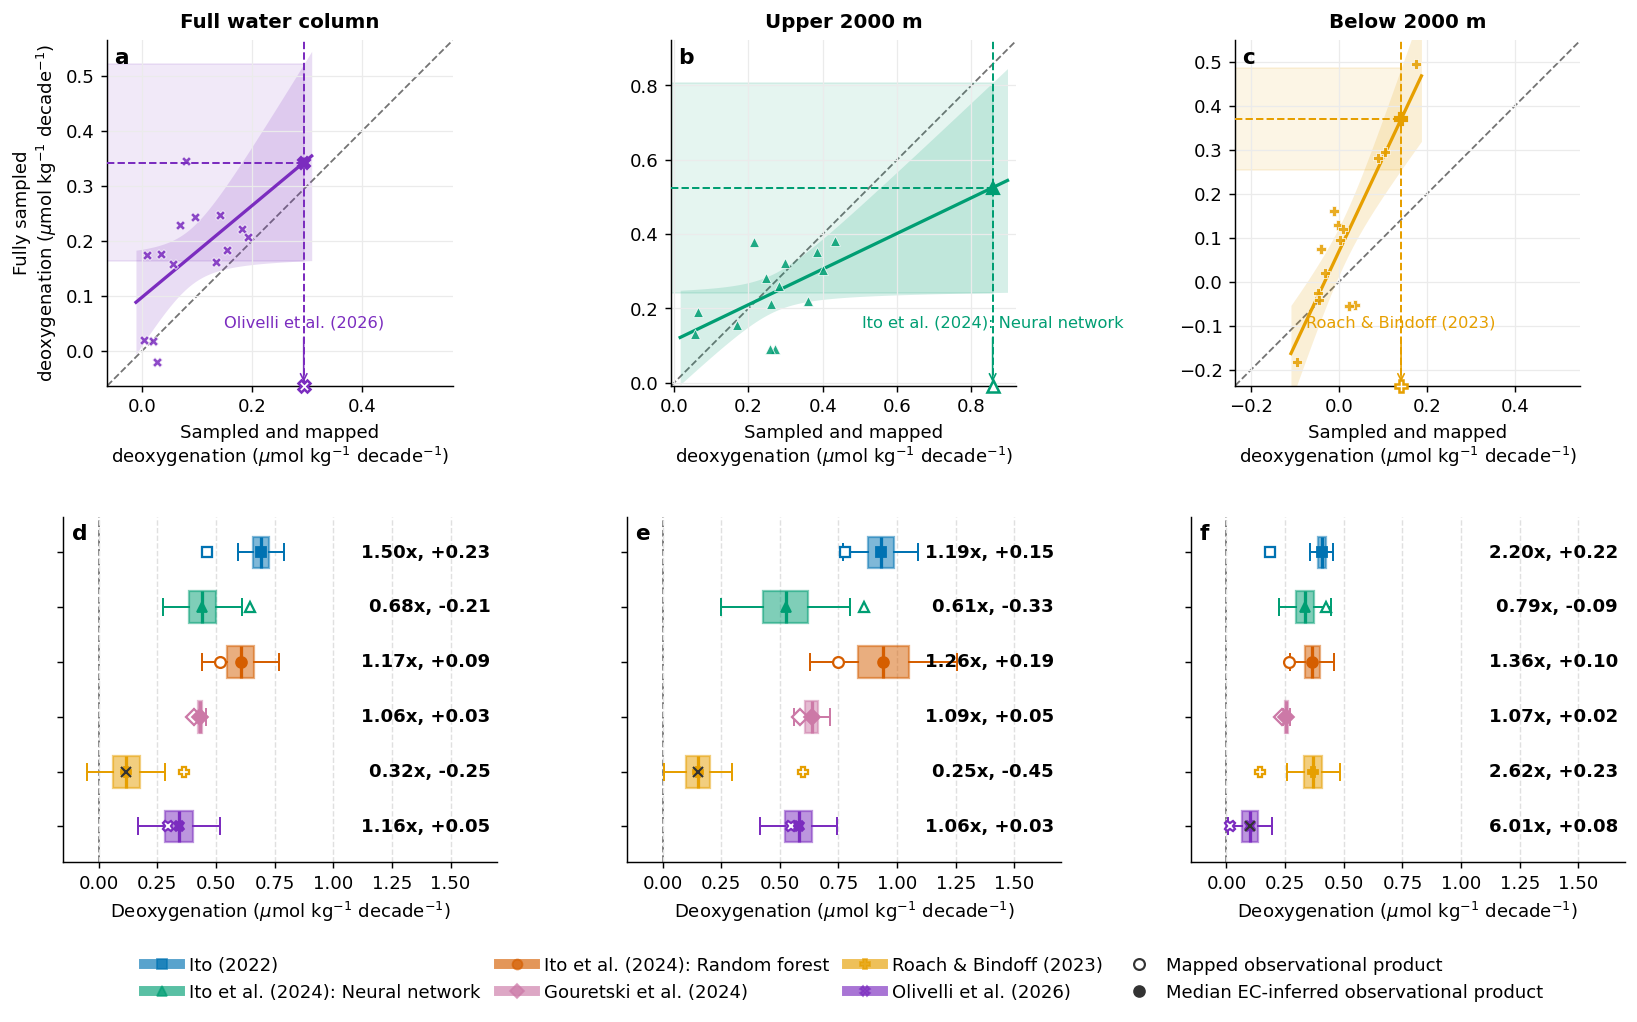

In [4]:
def draw_horizontal_box(ax, quantiles, y, color, height=0.58):
    stats = [{'label': '', 'whislo': quantiles[0.025], 'q1': quantiles[0.25],
              'med': quantiles[0.50], 'q3': quantiles[0.75],
              'whishi': quantiles[0.975], 'fliers': []}]
    artists = ax.bxp(stats, positions=[y], widths=height, vert=False,
                     patch_artist=True, showfliers=False, manage_ticks=False)
    artists['boxes'][0].set(facecolor=color, edgecolor=color, alpha=0.5, linewidth=1.25)
    for key in ('whiskers', 'caps'):
        for artist in artists[key]:
            artist.set(color=color, linewidth=1.1)
    artists['medians'][0].set(color=color, linewidth=1.8)

depth_order = list(DEPTHS)
fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.0))
fig.subplots_adjust(left=0.075, right=0.985, top=0.95, bottom=0.16,
                    wspace=0.30, hspace=0.38)

for col, depth in enumerate(depth_order):
    ax = axes[0, col]
    values = examples[depth]
    product = values['product']
    style = PRODUCT_STYLES[product]
    paired, observed = values['paired'], values['observed']
    x_data = paired['gap_filled'].to_numpy(float)
    y_data = paired['fully_sampled'].to_numpy(float)
    x_min, x_max = min(x_data.min(), observed), max(x_data.max(), observed)
    x_pad = max(0.05 * (x_max - x_min), 0.01)
    x_grid = np.linspace(x_min - x_pad, x_max + x_pad, 300)
    fit, y_fit, band_lo, band_hi = regression_with_confidence_band(paired, x_grid)
    _, ec_at_obs, ec_lo, ec_hi = regression_with_confidence_band(paired, np.asarray([observed]))
    inferred, inferred_lo, inferred_hi = float(ec_at_obs[0]), float(ec_lo[0]), float(ec_hi[0])
    all_values = np.concatenate([x_data, y_data, [observed, inferred_lo, inferred, inferred_hi]])
    low, high = np.nanmin(all_values), np.nanmax(all_values)
    pad = max(0.08 * (high - low), 0.01)
    limits = (low - pad, high + pad)
    ax.fill_between(x_grid, band_lo, band_hi, color=style['color'], alpha=0.16, linewidth=0)
    ax.plot(x_grid, y_fit, color=style['color'], lw=1.8)
    ax.scatter(x_data, y_data, s=30, marker=style['marker'], color=style['color'],
               edgecolor='white', linewidth=0.45, alpha=0.86, zorder=3)
    ax.plot(limits, limits, ls='--', lw=1, color='0.45', zorder=0)
    ax.axvline(observed, color=style['color'], ls='--', lw=1.1, zorder=4)
    ax.fill_betweenx([inferred_lo, inferred_hi], limits[0], observed,
                     color=style['color'], alpha=0.10, zorder=0)
    ax.hlines(inferred, limits[0], observed, color=style['color'], ls='--', lw=1.1, zorder=4)
    # Hollow marker: mapped observational estimate on the x axis.
    axis_marker_y = limits[0]
    ax.plot(observed, axis_marker_y, marker=style['marker'], ms=7.0, mfc='white',
            mec=style['color'], mew=1.4, linestyle='None', clip_on=False, zorder=7)
    # Solid marker: median EC-inferred fully sampled observational estimate.
    ax.plot(observed, inferred, marker=style['marker'], ms=7.0, mfc=style['color'],
            mec=style['color'], mew=1.2, linestyle='None', zorder=7)
    ax.annotate(
        PRODUCT_LABELS[product], xy=(observed, axis_marker_y),
        xytext=(observed, axis_marker_y + 0.16 * (limits[1] - limits[0])),
        ha='center', va='bottom', fontsize=9, color=style['color'],
        arrowprops=dict(arrowstyle='->', color=style['color'], lw=0.9),
        zorder=8,
    )
    ax.set(xlim=limits, ylim=limits)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(color='0.92', linewidth=0.7)
    ax.set_title(depth, fontsize=11, fontweight='bold', pad=7)
    ax.set_xlabel('Sampled and mapped\n' + r'deoxygenation ($\mu$mol kg$^{-1}$ decade$^{-1}$)', fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    if col == 0:
        ax.set_ylabel('Fully sampled\n' + r'deoxygenation ($\mu$mol kg$^{-1}$ decade$^{-1}$)', fontsize=10)
    ax.text(0.02, 0.98, chr(ord('a') + col), transform=ax.transAxes,
            ha='left', va='top', fontsize=12, fontweight='bold')

individual_quantiles = {}
all_box_values = [0.0]
for depth in depth_order:
    rows = all_ec.loc[all_ec['depth_label'] == depth]
    individual_quantiles[depth] = {}
    for _, row in rows.iterrows():
        product = str(row['product'])
        distribution = equal_weight_skewnormal_mixture(row.to_frame().T)
        individual_quantiles[depth][product] = distribution['quantiles']
        all_box_values.extend([distribution['quantiles'][0.025], distribution['quantiles'][0.975]])
xmin, xmax = np.nanmin(all_box_values), np.nanmax(all_box_values)
data_span = xmax - xmin
xpad = 0.08 * data_span
# Reserve a narrow right-hand region for multiplicative/additive annotations.
shared_xlim = (xmin - xpad, xmax + 0.34 * data_span)
annotation_x = shared_xlim[1] - 0.015 * (shared_xlim[1] - shared_xlim[0])
positions = np.arange(len(PRODUCT_ORDER), 0, -1)

for col, depth in enumerate(depth_order):
    ax = axes[1, col]
    rows = all_ec.loc[all_ec['depth_label'] == depth].copy()
    for y, product in zip(positions, PRODUCT_ORDER):
        style = PRODUCT_STYLES[product]
        quantiles = individual_quantiles[depth][product]
        draw_horizontal_box(ax, quantiles, y, style['color'])
        row = rows.loc[rows['product'].astype(str) == product].iloc[0]
        observed = float(row['gapfilled'])
        ec_median = float(quantiles[0.50])
        # Hollow observational marker and solid median EC-inferred marker.
        ax.plot(observed, y, marker=style['marker'], ms=6.0, mfc='white',
                mec=style['color'], mew=1.25, linestyle='None', zorder=7)
        ax.plot(ec_median, y, marker=style['marker'], ms=6.0, mfc=style['color'],
                mec=style['color'], mew=1.0, linestyle='None', zorder=8)
        ratio = ec_median / observed if observed != 0 else np.nan
        delta = ec_median - observed
        ax.text(annotation_x, y, f'{ratio:.2f}x, {delta:+.2f}',
                ha='right', va='center', fontsize=10, fontweight='bold')
        if not bool(row['valid_for_plot']):
            ax.plot(quantiles[0.50], y, marker='x', ms=6, mew=1.2,
                    color='0.2', linestyle='None', zorder=8)
    ax.axvline(0, color='0.45', ls='--', lw=1, zorder=0)
    ax.set_xlim(shared_xlim)
    ax.set_ylim(0.35, len(PRODUCT_ORDER) + 0.65)
    ax.set_yticks(positions)
    ax.set_yticklabels([])
    ax.grid(axis='x', color='0.88', linestyle='--', linewidth=0.8)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xlabel(r'Deoxygenation ($\mu$mol kg$^{-1}$ decade$^{-1}$)', fontsize=10)
    ax.text(0.02, 0.98, chr(ord('d') + col), transform=ax.transAxes,
            ha='left', va='top', fontsize=12, fontweight='bold')

for ax in axes.ravel():
    ax.spines[['top', 'right']].set_visible(False)
legend_handles = [
    Line2D([0], [0], marker=PRODUCT_STYLES[p]['marker'], color=PRODUCT_STYLES[p]['color'],
           lw=5.5, markerfacecolor=PRODUCT_STYLES[p]['color'], markersize=5.5,
           alpha=0.65, label=PRODUCT_LABELS[p]) for p in PRODUCT_ORDER
]
legend_handles += [
    Line2D([0], [0], marker='o', color='0.2', markerfacecolor='white',
           markeredgewidth=1.2, linestyle='None', label='Mapped observational product'),
    Line2D([0], [0], marker='o', color='0.2', markerfacecolor='0.2',
           linestyle='None', label='Median EC-inferred observational product'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.53, 0.01),
           ncol=4, frameon=False, fontsize=10, columnspacing=1.0, handletextpad=0.5)
OUTPUT_STEM.parent.mkdir(parents=True, exist_ok=True)
output = OUTPUT_STEM.with_suffix('.pdf')
fig.savefig(output, bbox_inches='tight', pad_inches=0.04)
print(f'Saved {output}')
plt.show()


## Reproducibility checks

In [5]:
assert set(all_ec['depth_label'].astype(str)) == set(DEPTHS)
assert all(all_ec.groupby('depth_label', observed=False).size().reindex(DEPTHS) == len(PRODUCT_ORDER))
assert 'Olivelli(2026)' in set(all_ec['product'].astype(str))
assert OUTPUT_STEM.with_suffix('.pdf').exists()
print('Checks passed: 3 depths x 6 reconstruction-specific ECs, including Olivelli; PDF written.')


Checks passed: 3 depths x 6 reconstruction-specific ECs, including Olivelli; PDF written.
